# LSTM with GloVe 6B 100d

This notebook trains a LSTM model to classify a news article into one of five bias labels using GloVe embeddings for each word in each article. 

## Import

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader           

from collections import Counter
from itertools import cycle
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight

import skorch
from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

glove_file = 'glove.6B/glove.6B.100d.txt'
if not os.path.exists(glove_file):
    raise FileNotFoundError(f"{glove_file} not found. Please download it from https://nlp.stanford.edu/projects/glove/ and place it in your working directory.")

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We chose GloVe over word2vec as the pretrained model has larger vocab more robust, more reasons why here, over us training our own word2vec embedding with our limited sample of n<5000 

We chose the 6B model with 100 dimensions as we are running our models on local and our compute power is limited. 

In [2]:
# Load preprocessed data
train = pd.read_csv('transformers_train_preprocessed.csv')
test = pd.read_csv('transformers_test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Number of classes: 5


In [3]:
# check 
train.head(5)

,Title,cleaned_text,Bias
0,Reminder: Trump is a demented criminal president,,left
1,Hamas Frees 4 Israeli Soldiers As Part Of Gaza...,"TEL AVIV, Israel (AP) - Four female Israeli so...",left
2,These Progressives Will Guide Us Through the D...,"Without a doubt, 2025 is going to be tough-but...",left
3,'It's a free country' - but some White House s...,White House staffers in the Office of Legislat...,left
4,VIDEO: 'Crazy' Winter Storm Forces Georgia Dri...,"A winter storm that hit the Atlanta, Georgia, ...",right


## Global Variables

In [4]:
batch_size = 32
criterion = nn.CrossEntropyLoss()
torch.manual_seed(42)
np.random.seed(42)

## Build Vocab and Embeddings

In [5]:
def tokenize(text):
    return text.lower().split()
    
def build_vocab(texts):
    vocab = Counter()
    for text in texts:
        tokens = tokenize(text)
        vocab.update(tokens)
    return vocab

def load_glove_embeddings(glove_file, vocab, embedding_dim):
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.strip().split()
            # skip any malformed lines
            if len(parts) != embedding_dim + 1:
                continue
            word = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            embeddings_index[word] = vector

    # Special tokens
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    pad_vec = np.zeros(embedding_dim, dtype=np.float32)
    unk_vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)

    # Build list of vectors
    embedding_list = [pad_vec, unk_vec]
    for word in sorted(vocab):
        word2idx[word] = len(word2idx)
        vec = embeddings_index.get(word)
        if vec is None:
            vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)
        embedding_list.append(vec)

    embedding_matrix = np.asarray(embedding_list, dtype=np.float32)  
    print("Embedding matrix shape:", embedding_matrix.shape)
    embedding_tensor = torch.from_numpy(embedding_matrix)      

    return word2idx, embedding_tensor, embeddings_index


We use simple white space tokenizer to use with GloVe which is word based to feed words sequentially into LSTM. 

In [6]:
def encode_text(texts, word2idx, max_len=128):
    encoded = []
    for text in texts:
        tokens = tokenize(text)
        idxs = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
        if len(idxs) < max_len:
            idxs += [word2idx['<PAD>']] * (max_len - len(idxs))
        else:
            idxs = idxs[:max_len]
        encoded.append(idxs)
    return torch.tensor(encoded)

In [7]:
vocab = build_vocab(train['cleaned_text'])        
embedding_dim = 100

word2idx, embedding_tensor, embeddings_index = load_glove_embeddings(glove_file, vocab, embedding_dim)

# check embedding match:
idx = word2idx.get('trump')
# check loaded embedding tensor directly
print("Loaded embedding tensor first 5 dims:", embedding_tensor[idx][:5])
# compare with original GloVe
print("Original GloVe vector first 5 dims:", embeddings_index['trump'][:5])

Embedding matrix shape: (73413, 100)
Loaded embedding tensor first 5 dims: tensor([-0.1573, -0.7550,  0.3684, -0.1896, -0.1690])
Original GloVe vector first 5 dims: [-0.15731 -0.75503  0.36845 -0.18958 -0.16896]


In [8]:
max_len = 128  # maximum number of tokens per article

# Encode texts to fixed‑length index tensors
X_train = encode_text(train['cleaned_text'], word2idx, max_len)
X_test = encode_text(test['cleaned_text'], word2idx, max_len)

# Convert label arrays to torch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

class EncodedTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx] 

# Create dataset instances
train_dataset = EncodedTextDataset(X_train, y_train_tensor)
test_dataset = EncodedTextDataset(X_test, y_test_tensor)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train batches: 55 | Test batches: 14


## LSTM

In [9]:
class LSTMModule(nn.Module):
    def __init__(self,
                 embedding_tensor,
                 hidden_dim=128,
                 num_layers=1,
                 bidirectional=False,
                 dropout=0.3,
                 num_classes=5):            
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor, freeze=True, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_tensor.size(1),
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1),
                            num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        if self.bidirectional:
            feat = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            feat = h_n[-1]
        return self.fc(feat)

We do not train the GloVe embedding or SFT it for our use case by setting freeze=True and lock padding index so that padding stays at zero and cannot drift.

In [10]:
X_np = X_train.numpy()         
y_np = y_train_tensor.numpy()

In [11]:
# Handled imbalanced classes

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_np), y=y_np)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [12]:
#for debugging, setting this toggle to True means that the test set is included in validation set
USE_TEST_AS_VALID = False 

In [13]:
train_split = predefined_split(test_dataset) if USE_TEST_AS_VALID else ValidSplit(0.2, stratified=True)
    
net = NeuralNetClassifier(
    module=LSTMModule,
    module__embedding_tensor=embedding_tensor,
    criterion=partial(nn.CrossEntropyLoss, weight=class_weights_tensor),
    optimizer=torch.optim.Adam,
    lr=1e-3,
    batch_size=32,
    max_epochs=20,
    device=device,
    train_split=train_split,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(policy=ReduceLROnPlateau,
                   monitor='valid_f1',  
                   factor=0.5,
                   patience=5,
                   verbose=True),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

### Hyperparameter Tuning

In [14]:
# as following exactly as in FFNN would give us 972 folds and require too much compute, we lower the params to those chosen by the 2 FFNN model
param_grid = {
    'module__hidden_dim':    [256, 512], 
    'module__num_layers':    [1, 2], 
    'module__bidirectional': [False, True],
    'module__dropout':       [0.5], #both FFNN modles chose 0.5
    'lr':                    [0.0005, 0.001], 
    'batch_size':            [16] #both FFNN modles chose 16
}


In [15]:
search = GridSearchCV(
    net,
    param_grid=param_grid,                
    cv=3,                     # 3‑fold inner CV
    scoring='f1_weighted',       
    refit=True,               # keep best_ estimator
    verbose=2,
    n_jobs=1                  
)

search.fit(X_np, y_np)        # skorch handles GPU inside each fit

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.2157      0.2190        1.6193       0.4464      0.3540        1.6100  0.0005  2.0944
      2       0.3616      0.3611        1.5917       0.3090      0.3136        1.6075  0.0005  1.8615
      3       0.3380      0.3544        1.5592       0.1545      0.1473        1.6285  0.0005  1.7752
      4       0.3273      0.3344        1.5006       0.2361      0.2433        1.6244  0.0005  1.8070
      5       0.3305      0.3297        1.4028       0.1803      0.1787        1.7600  0.0005  1.8070
Stopping since valid_f1 has not improved in the last 5 epochs.
[CV] END batch_size=16, lr=0.0005, module__bidirectional=False, module__dropout=0.5, module__hidden_dim=256, module__num_layers=1; total time=  12.6s


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.1867      0.1962        1.6143       0.1974      0.1486        1.6141  0.0005  1.7481
      2       0.3487      0.3603        1.5805       0.3305      0.3304        1.6144  0.0005  1.7763
      3       0.3916      0.3984        1.5396       0.1760      0.1432        1.6387  0.0005  1.8796
      4       0.3294      0.3411        1.4823       0.2017      0.2252        1.7113  0.0005  1.7642
      5       0.4163      0.4227        1.4106       0.1760      0.1486        1.6822  0.0005  1.7490
      6       0.3830      0.3914        1.4318       0.2017      0.2186        1.6393  0.0005  1.7908
Stopping since valid_f1 has not improved in the last 5 epochs.
[CV] END batch_size=16, lr=0.0005, module__bidirectional=False, module__dropout=0.5, module__hidden_dim=256, module__num_

...

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.3015      0.3398        1.5677       0.3205      0.3431        1.5613  0.0010  6.7695
      2       0.3562      0.3926        1.4546       0.3077      0.3292        1.4800  0.0010  6.7899
      3       0.4067      0.4338        1.3160       0.3590      0.3791        1.6472  0.0010  6.7125
      4       0.4903      0.5129        1.1468       0.3932      0.4105        1.8289  0.0010  6.7016
      5       0.4839      0.4973        1.2074       0.1453      0.1179        1.7668  0.0010  6.6674
      6       0.4571      0.4699        1.1547       0.3632      0.3844        1.7947  0.0010  6.7126
      7       0.6792      0.6844        0.7029       0.3761      0.3974        1.8774  0.0010  6.7509
      8       0.7189      0.7203        0.5742       0.4103      0.4288        2.1

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.2969      0.3296        1.5709       0.3371      0.3613        1.5209  0.0010  5.8032
      2       0.3791      0.4144        1.4619       0.3543      0.3932        1.4881  0.0010  5.7721
      3       0.4149      0.4434        1.3478       0.3943      0.4378        1.4546  0.0010  5.7546
      4       0.4728      0.4975        1.2246       0.5371      0.5137        1.5537  0.0010  5.7466
      5       0.5236      0.5441        1.1037       0.4771      0.5034        1.6302  0.0010  5.7566
      6       0.5787      0.5932        0.9446       0.4686      0.5019        1.7298  0.0010  5.7374
      7       0.6695      0.6779        0.7515       0.5029      0.5161        2.1447  0.0010  5.7583
      8       0.7439      0.7501        0.5631       0.5400      0.5445        2.3

GridSearchCV(cv=3,
             estimator=NeuralNetClassifier(_params_to_validate={'module__embedding_tensor'}, batch_size=32, callbacks=[<skorch.callbacks.scoring.EpochScoring object at 0x345eabb60>, <skorch.callbacks.scoring.EpochScoring object at 0x328a3b650>, <skorch.callbacks.scoring.EpochScoring object at 0x345ea9d60>, <skorch.callbacks.scoring.EpochScoring object at 0x345...
        [-0.3253,  1.0350,  0.7410,  ...,  0.2066,  0.0917, -0.0868]]), optimizer=<class 'torch.optim.adam.Adam'>, predict_nonlinearity='auto', torch_load_kwargs=None, train_split=<skorch.dataset.ValidSplit object at 0x345eabb90>, use_caching='auto', verbose=1, warm_start=False),
             n_jobs=1,
             param_grid={'batch_size': [16], 'lr': [0.0005, 0.001],
                         'module__bidirectional': [False, True],
                         'module__dropout': [0.5],
                         'module__hidden_dim': [256, 512],
                         'module__num_layers': [1, 2]},
             scoring='f1_weighted', verbose=2)

In [16]:
best_net = search.best_estimator_
best_net.save_params(f_params='lstm_best.pt')
cv_df = pd.DataFrame(search.cv_results_)

best_params = search.best_params_

# build a boolean mask over each param_* column
mask = pd.Series(True, index=cv_df.index)
for key, value in best_params.items():
    mask &= (cv_df[f'param_{key}'] == value)

best_run = cv_df[mask]

In [ ]:
history = best_net.history
print(f"Actual epochs ran: {len(history)-1}")

In [38]:
# Find the epoch with the best validation performance (using valid_f1 as the criterion)
best_epoch_idx = max(range(len(history)), key=lambda i: history[i]['valid_f1'])
best_epoch = history[best_epoch_idx]

# Get the training metrics for the best model
best_train_acc = best_epoch['train_acc']
best_train_f1 = best_epoch['train_f1']

# Also get the validation metrics from the same epoch
best_valid_acc = best_epoch['valid_acc']
best_valid_f1 = best_epoch['valid_f1']

print(f"Best model (based on validation F1) was from epoch {best_epoch_idx+1}")
print(f"Best model training accuracy: {best_train_acc:.4f}")
print(f"Best model training weighted F1 score: {best_train_f1:.4f}")
print(f"Best model validation accuracy: {best_valid_acc:.4f}")
print(f"Best model validation F1 score: {best_valid_f1:.4f}")

# If you're using a best_net variable that already contains the best model
# (which is typical in skorch), you can also do:
if 'best_net' in globals():
    print("\nBest model metrics from best_net:")
    best_epoch_metrics = best_net.history[-1]
    print(f"Training accuracy: {best_epoch_metrics['train_acc']:.4f}")
    print(f"Training weighted F1 score: {best_epoch_metrics['train_f1']:.4f}")

Best model (based on validation F1) was from epoch 6
Best model training accuracy: 0.5644
Best model training weighted F1 score: 0.5728
Best model validation accuracy: 0.4057
Best model validation F1 score: 0.4423

Best model metrics from best_net:
Training accuracy: 0.5644
Training weighted F1 score: 0.5728


In [18]:
best_run.T

,13
mean_fit_time,62.327783
std_fit_time,14.353992
mean_score_time,0.601667
std_score_time,0.035501
param_batch_size,16
param_lr,0.001
param_module__bidirectional,True
param_module__dropout,0.5
param_module__hidden_dim,256
param_module__num_layers,2


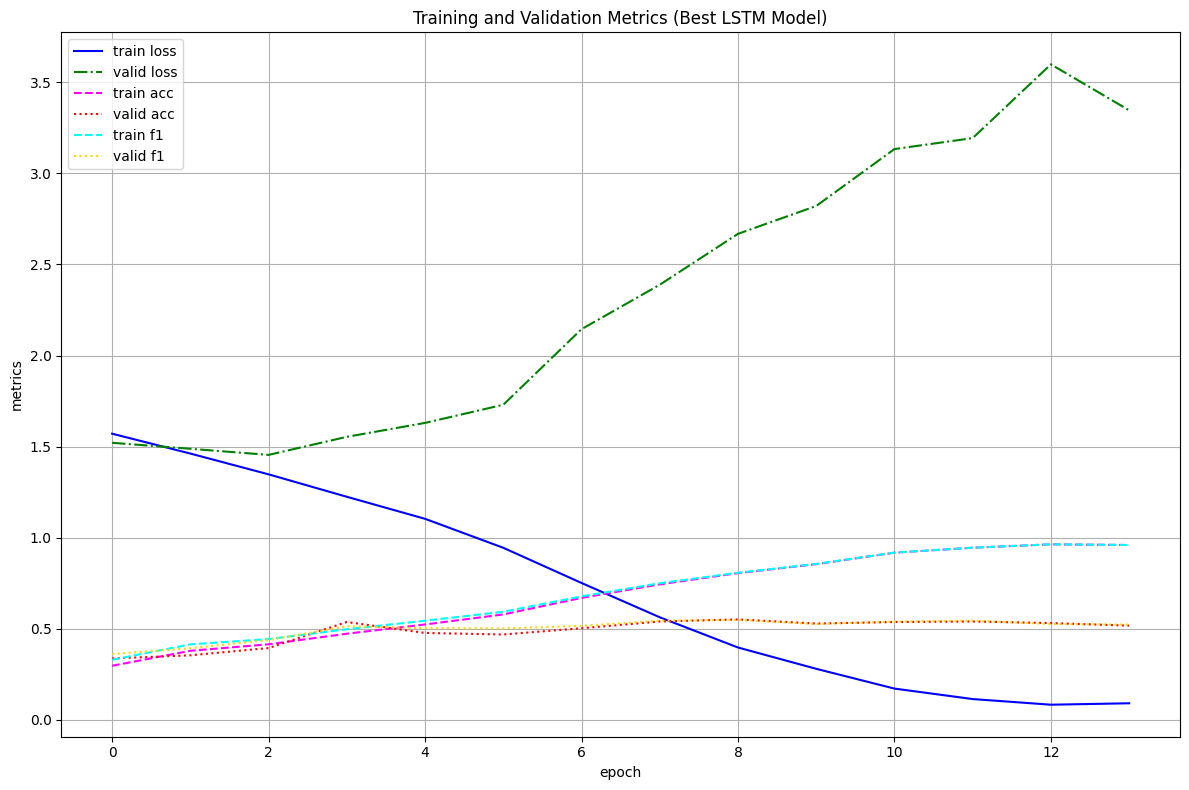

In [19]:
def plot_lstm_learning_curves(net):
    history = net.history

    plt.figure(figsize=(12, 8)) 

    # Plot loss
    plt.plot(history[:, 'train_loss'], label='train loss', color='blue')
    plt.plot(history[:, 'valid_loss'], label='valid loss', color='green', linestyle='-.')
    
    # Plot accuracy
    plt.plot(history[:, 'train_acc'], label='train acc', color='magenta', linestyle='--')
    plt.plot(history[:, 'valid_acc'], label='valid acc', color='red', linestyle=':')
    
    # Plot F1
    plt.plot(history[:, 'train_f1'], label='train f1', color='cyan', linestyle='--')
    plt.plot(history[:, 'valid_f1'], label='valid f1', color='gold', linestyle=':')

    plt.title('Training and Validation Metrics (Best LSTM Model)')
    plt.xlabel('epoch')
    plt.ylabel('metrics')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call this with the best LSTM model found
plot_lstm_learning_curves(search.best_estimator_)

In GridSearch, we configured max_epoch=20. However, the best params found stopped at epoch=13 due to early stop as weighted_f1 has not improved in the last 5 epoch (epoch 8-13). From the chart, we can see signs of overfitting for epoch 6. Validation loss is rapidly increasing while training loss is falling, and at the same time, weighted_f1 has plateaued while accuracy is increasing. This means that there is a trade off happening between accuracy with precision and recall as weighted_f1 is constant. 

At epoch 6, model has reached a good balance point. Training loss has decreased significantly from start value and validation metrics have not begun diverging significantly. Both accuracy and weighted f1 for training and validation remain reasonably aligned. Hence, we will stop training the model at epoch=6. 

### Train LSTM with Best Params

In [27]:
best_net.set_params(max_epochs=6)  #set to prevent overfit 
best_net.fit(X_train, y_train) #retrain on full set - test is now the hold out test set

# Evaluate
preds = best_net.predict(X_test)
probs = best_net.predict_proba(X_test)

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='weighted')
report = classification_report(y_test, preds, target_names=label_encoder.classes_, digits=4)

print(f"LSTM Accuracy (epoch 6): {acc * 100:.2f}%")
print(f"LSTM Weighted F1-score (epoch 6): {f1:.4f}")
print("\nClassification Report (epoch 6):\n", report)

Re-initializing module because the following parameters were re-set: bidirectional, dropout, embedding_tensor, hidden_dim, num_layers.
Re-initializing criterion.
Re-initializing optimizer.


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.2618      0.2800        1.6439       0.3514      0.3779        1.5180  0.0010  5.7055
      2       0.3662      0.3906        1.4965       0.4286      0.4121        1.5490  0.0010  5.6499
      3       0.3920      0.4196        1.4082       0.4229      0.4412        1.5231  0.0010  5.7063
      4       0.4843      0.5113        1.2343       0.3971      0.4419        1.5425  0.0010  5.6805
      5       0.5343      0.5496        1.0871       0.4314      0.4349        1.8156  0.0010  5.6149
      6       0.5644      0.5728        0.9445       0.4057      0.4423        1.6970  0.0010  5.7053
LSTM Accuracy (epoch 6): 37.76%
LSTM Weighted F1-score (epoch 6): 0.4146

Classification Report (epoch 6):
               precision    recall  f1-score   support

      center     0.12

## Evaluation

In [28]:
y_pred = best_net.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4)

print(f"LSTM Accuracy: {acc * 100:.2f}%")
print(f"LSTM Weighted F1-score: {f1:.4f}")
print("\nClassification Report:\n", report)

LSTM Accuracy: 37.76%
LSTM Weighted F1-score: 0.4146

Classification Report:
               precision    recall  f1-score   support

      center     0.1250    0.1463    0.1348        41
   lean left     0.2421    0.3770    0.2949        61
  lean right     0.1486    0.2973    0.1982        37
        left     0.8016    0.4550    0.5805       222
       right     0.2553    0.3158    0.2824        76

    accuracy                         0.3776       437
   macro avg     0.3145    0.3183    0.2981       437
weighted avg     0.5097    0.3776    0.4146       437



### Classification Report Commentary 
The LSTM achieves 37.76% accuracy and a weighted F1-score of 0.4146, positioning its performance between the FFNN with TD-IDF (72.54% accuracy, 0.6109 weighted F1) and the FFNN with GloVe (32.27% accuracy, 0.3372 weighted F1). 

Comparing the implementations of FFNN and LSTM with the same embedding method of GloVe, as expected we can see that LSTM will outperform. FFNN took the average of embeddings while LSTM took in the data sequentially to learn temporal patterns in the data. 

Moving to BERT and Llama, we expect performance to increase for attention based models that account for semantic meaning and temporal patterns over purely sequence based LSTM. 

Comparing the better FFNN implementation with TD-IDF against LSTM with GloVe, unexpectedly, LSTM despite being a newer architecture, underperforms the classical method. 

Several reasons could have contributed to this. 

Firstly, we took a max sequence length of 128 because of memory issues. In this implementation, we inadvertantly tested our original hypothesis of if using only the first 100 words is enough to classify an article to the right label. Do note that BERT and Llama subsequently use 128 as well and we will discuss their performance in the following notebooks. This could potentially be unfair to compare with FFNN TD-IDF who analyses the entire article for vocabulary distributions. 

Secondly, we believe this is due to FFNN being able to generalize quickly on small data sets like we are using (<2000) while LSTM would need more data to learn the temporal patterns. 

### Confusion Matrices

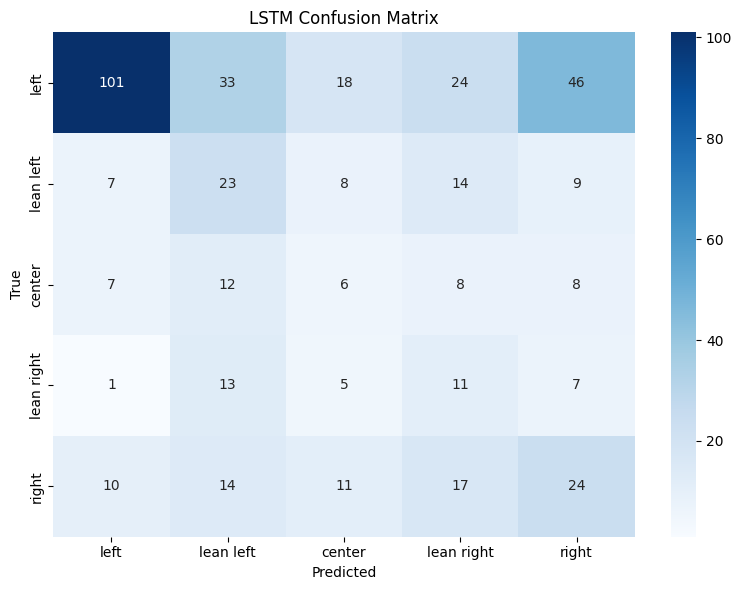

In [29]:
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
y_pred = best_net.predict(X_test_np)

# Define correct label order
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

cm = confusion_matrix(y_test_np, y_pred, labels=label_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.show()

-	The LSTM performs best on the "left" class, with 101/222 (45%) correct predictions, showing strong recognition of the dominant class. 

- Very concerningly, the model shows some confusion between distant ideological positions (10 "right" instances misclassified as "left"). "Right" predictions are distributed across all classes, suggesting lower precision for this label. 

-	Compared to the FFNN, the LSTM shows:
	- 	Weaker boundary resolution
	- 	More confusion between ideological opposites, such as "right" being predicted as "left" and vice versa, which  is much more problematic failure than when predicting the adjacent class on the spectrum. 

In [30]:
classes = best_net.classes_
class_names = label_encoder.classes_

for i, class_idx in enumerate(classes):
    class_label = class_names[class_idx]
    
    y_true_binary = (y_test_np == class_idx).astype(int)
    y_pred_binary = (y_pred == class_idx).astype(int)

    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{class_label}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[354  42]
 [ 35   6]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[304  72]
 [ 38  23]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[337  63]
 [ 26  11]]

One-vs-Rest Confusion Matrix for class 'left':
[[190  25]
 [121 101]]

One-vs-Rest Confusion Matrix for class 'right':
[[291  70]
 [ 52  24]]


## ROC-AUC

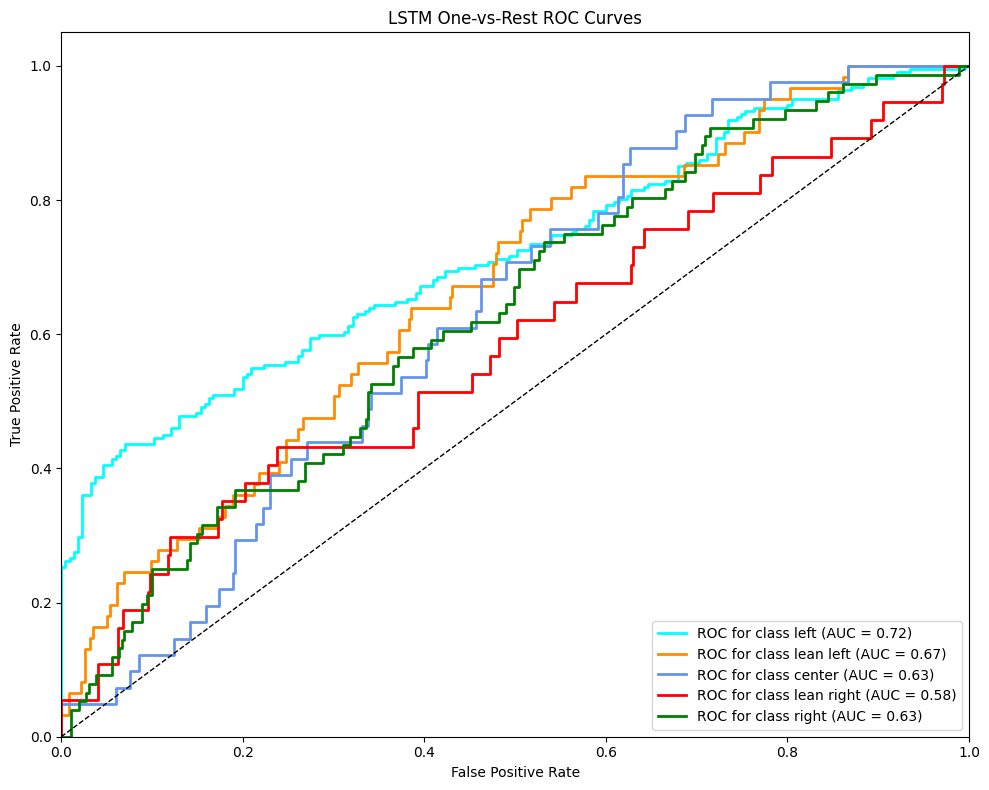

In [31]:
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
classes = best_net.classes_
class_names = label_encoder.classes_

y_test_binarized = label_binarize(y_test_np, classes=range(len(classes)))
y_score = best_net.predict_proba(X_test_np)

fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC data
for label, idx in zip(label_order, label_indices):
    fpr[label], tpr[label], _ = roc_curve(y_test_binarized[:, idx], y_score[:, idx])
    roc_auc[label] = roc_auc_score(y_test_binarized[:, idx], y_score[:, idx])

# Plot
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])

for label, color in zip(label_order, colors):
    plt.plot(fpr[label], tpr[label], color=color, lw=2,
             label=f'ROC for class {label} (AUC = {roc_auc[label]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM One-vs-Rest ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [32]:
macro_auc = roc_auc_score(y_test_binarized, y_score, average='weighted')
print(f"Macro-average ROC AUC: {macro_auc:.4f}")

Macro-average ROC AUC: 0.6768


ROC-AUC values for the LSTM are poor with a floor of 0.63 and a high of 0.72. It is notably lower than FFNN TD-IDF which has a floor of 0.79. 

The macro-average ROC-AUC at 0.6768 is lower than for FFNN at 0.8773. These results show that the LSTM has weaker class separability. The ROC curves indicate that the model has not learned strong decision boundaries and is likely influenced by the class imbalance.

### Performance Metrics Evaluation Summary

| Model            | Accuracy | Weighted F1 |
|------------------|----------|-------------|
| Decision Tree    | 59.27    | 60.29       |
| FFNN (TD-IDF)    | 69.79    | 68.85       |
| FFNN (GloVe)     | 32.27    | 33.72       |
| LSTM             | 37.76    | 41.46       |

### Final Remarks

Overall, the LSTM underperforms compared to the FFNN with TF-IDF, with lower accuracy and weaker ROC-AUC across all classes. With a small dataset size (n < 3000), FFNNs generalize faster and more reliably, while LSTMs typically require more data and longer training to reach optimal performance. 

Comparing FFNN (TF-IDF) and LSTM, the results suggest that vocabulary - as captured by TF-IDF features, is more important than the temporal patterns that LSTM models are designed to capture.

Comparing FFNN (GloVe) and LSTM, the LSTM performs better, showing that there is some information related to the bias label that can be learnt from the sequential patterns in the data that can benefit the LSTM's architecture over a simple average of the embeddings into a flat input. 

Overall, the results show that depending on the scale of data and the problem at hand, classical methods can still outperform newer deep learning models. We now move onto transformers, with reduced confidence in our initial hypothesis that newer models will always out perform older ones. 